In [1]:
!pip install matplotlib scikit-learn seaborn pillow 

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns

In [3]:
# ==================== CONFIG ====================
BATCH_SIZE = 32
NUM_EPOCHS = 15
LEARNING_RATE = 0.001
IMAGE_SIZE = (224, 224)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

# ==================== DATA AUGMENTATION ====================
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

TensorFlow version: 2.10.1
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
train_generator = train_datagen.flow_from_directory(
    'C:/E0323036-SEM6/dl_med/chest_xray/train',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = test_datagen.flow_from_directory(
    'C:/E0323036-SEM6/dl_med/chest_xray/val',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    'C:/E0323036-SEM6/dl_med/chest_xray/test',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f"Train samples: {train_generator.samples}")
print(f"Val samples: {val_generator.samples}")
print(f"Test samples: {test_generator.samples}")
print(f"Classes: {train_generator.class_indices}")



Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Train samples: 5216
Val samples: 16
Test samples: 624
Classes: {'NORMAL': 0, 'PNEUMONIA': 1}


In [6]:
# ==================== BUILD CNN MODEL ====================
def build_cnn_model(input_shape=(224, 224, 3), num_classes=2):
    model = models.Sequential([
        # Block 1
        layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Block 2
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Block 3
        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Block 4
        layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Classifier
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    
    return model

# Build model
model = build_cnn_model(input_shape=(224, 224, 3), num_classes=2)
model.summary()

# ==================== COMPILE MODEL ====================
optimizer = keras.optimizers.Adam(learning_rate=LEARNING_RATE)
model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ==================== CALLBACKS ====================
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        'pneumonia_model_best.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

# ==================== TRAINING ====================
print("\n" + "="*50)
print("Starting Training...")
print("="*50 + "\n")

history = model.fit(
    train_generator,
    epochs=NUM_EPOCHS,
    validation_data=val_generator
)

print("\nTraining Complete!")
print("\n" + "="*50)
print("Testing Model...")
print("="*50 + "\n")


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_4 (Conv2D)           (None, 224, 224, 32)      896       
                                                                 
 batch_normalization_4 (Batc  (None, 224, 224, 32)     128       
 hNormalization)                                                 
                                                                 
 max_pooling2d_4 (MaxPooling  (None, 112, 112, 32)     0         
 2D)                                                             
                                                                 
 dropout_6 (Dropout)         (None, 112, 112, 32)      0         
                                                                 
 conv2d_5 (Conv2D)           (None, 112, 112, 64)      18496     
                                                                 
 batch_normalization_5 (Batc  (None, 112, 112, 64)    

20/20 [==============================] - 3s 160ms/step
Test Accuracy:  0.7436
Test Precision: 0.7582
Test Recall:    0.7436
Test F1-Score:  0.7187


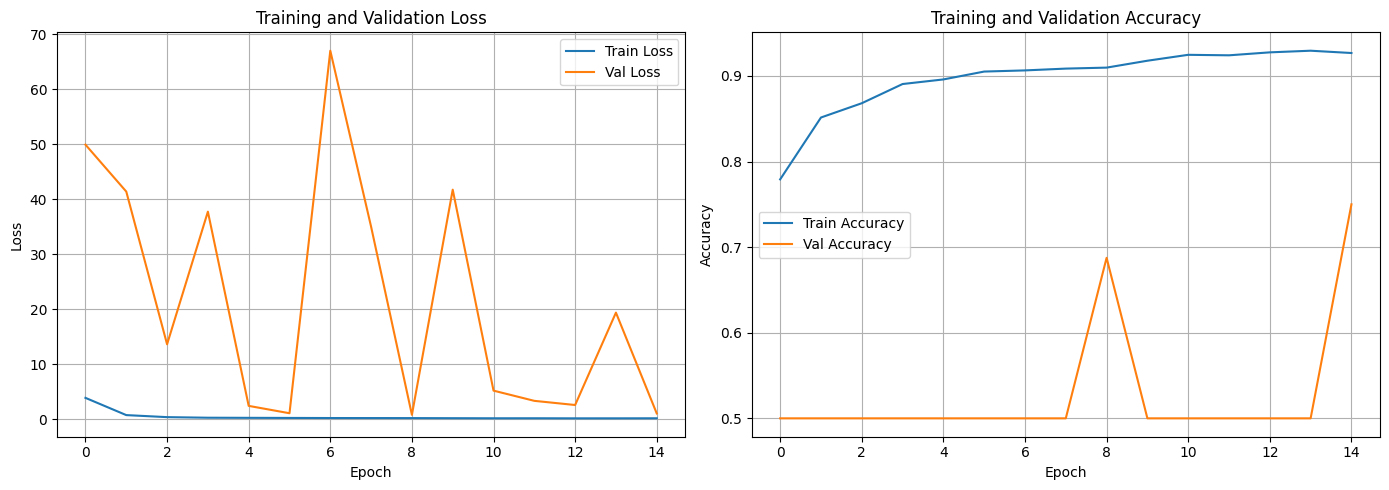

RuntimeError: Can't decrement id ref count (unable to extend file properly)

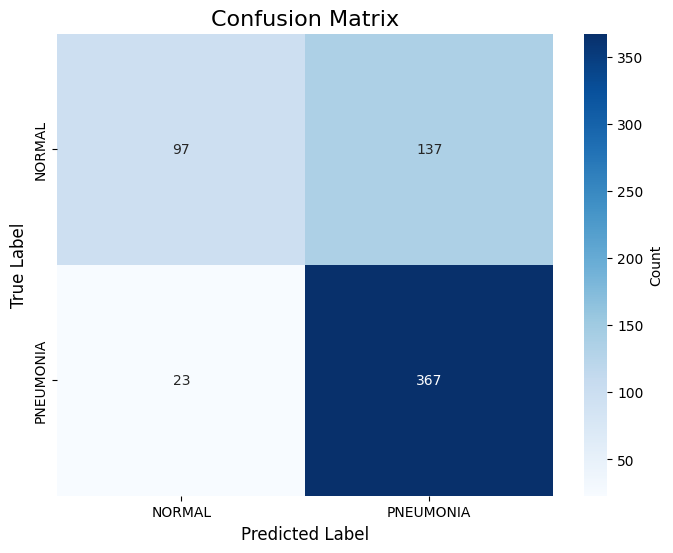

In [10]:

test_predictions = model.predict(test_generator)
test_preds_classes = np.argmax(test_predictions, axis=1)
test_true_labels = test_generator.classes
test_accuracy = accuracy_score(test_true_labels, test_preds_classes)
test_precision = precision_score(test_true_labels, test_preds_classes, average='weighted')
test_recall = recall_score(test_true_labels, test_preds_classes, average='weighted')
test_f1 = f1_score(test_true_labels, test_preds_classes, average='weighted')

print(f"Test Accuracy:  {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall:    {test_recall:.4f}")
print(f"Test F1-Score:  {test_f1:.4f}")


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True)
axes[1].plot(history.history['accuracy'], label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
plt.show()
cm = confusion_matrix(test_true_labels, test_preds_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NORMAL', 'PNEUMONIA'],
            yticklabels=['NORMAL', 'PNEUMONIA'],
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix', fontsize=16)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)

model.save('pneumonia_model.h5')
model.save('pneumonia_model_tf')

print("\n✓ Model saved as 'pneumonia_model.h5'")
print("✓ Model saved as 'pneumonia_model_tf' (TensorFlow format)")
print("✓ Training history saved as 'training_history.png'")
print("✓ Confusion matrix saved as 'confusion_matrix.png'")

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np
import sys
MODEL_DIR = 'pneumonia_model_savedmodel'

try:
    model = tf.keras.models.load_model(MODEL_DIR)
    print(f"✓ Model loaded successfully from {MODEL_DIR}")
except Exception as e:
    print(f"Error loading model: {e}")
    print(f"Make sure the model exists at: {MODEL_DIR}")
    sys.exit(1)

def predict_pneumonia(image_path):
    """Predict pneumonia from a single X-ray image"""
    
    try:
        image = load_img(image_path, target_size=(224, 224))
        image_array = img_to_array(image) / 255.0
        image_array = np.expand_dims(image_array, axis=0)
        prediction = model.predict(image_array, verbose=0)
        predicted_class = np.argmax(prediction[0])
        confidence = prediction[0][predicted_class]
        
        class_names = ['NORMAL', 'PNEUMONIA']
        predicted_label = class_names[predicted_class]
        
        print(f"\n{'='*50}")
        print(f"Image: {image_path}")
        print(f"Prediction: {predicted_label}")
        print(f"Confidence: {confidence:.4f}")
        print(f"{'='*50}\n")

        print("Class Probabilities:")
        for class_name, prob in zip(class_names, prediction[0]):
            print(f"  {class_name}: {prob:.4f}")
        
        return predicted_label, confidence
        
    except Exception as e:
        print(f"Error predicting image: {e}")
        return None, None

if __name__ == "__main__":
    if len(sys.argv) > 1:
        image_path = sys.argv[1]
        predict_pneumonia(image_path)
    else:
        print("Usage: python predict_pneumonia_tf_fixed.py <image_path>")
        print("Example: python predict_pneumonia_tf_fixed.py chest_xray.png")